
--- Analysis for Biomass Energy ---


C:\Users\W11\AppData\Local\Temp\ipykernel_27180\1378698740.py:40: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.cross(p2 - p1, points - p1) / np.linalg.norm(p2 - p1)


>> Algorithmic Optimal k for Biomass: 3 <<

--- Analysis for Solar Energy ---


C:\Users\W11\AppData\Local\Temp\ipykernel_27180\1378698740.py:40: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.cross(p2 - p1, points - p1) / np.linalg.norm(p2 - p1)


>> Algorithmic Optimal k for Solar: 3 <<

--- Analysis for Hydropower Energy ---


C:\Users\W11\AppData\Local\Temp\ipykernel_27180\1378698740.py:40: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.cross(p2 - p1, points - p1) / np.linalg.norm(p2 - p1)


>> Algorithmic Optimal k for Hydropower: 3 <<

--- Analysis for Wind Energy ---


C:\Users\W11\AppData\Local\Temp\ipykernel_27180\1378698740.py:40: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.cross(p2 - p1, points - p1) / np.linalg.norm(p2 - p1)


>> Algorithmic Optimal k for Wind: 2 <<


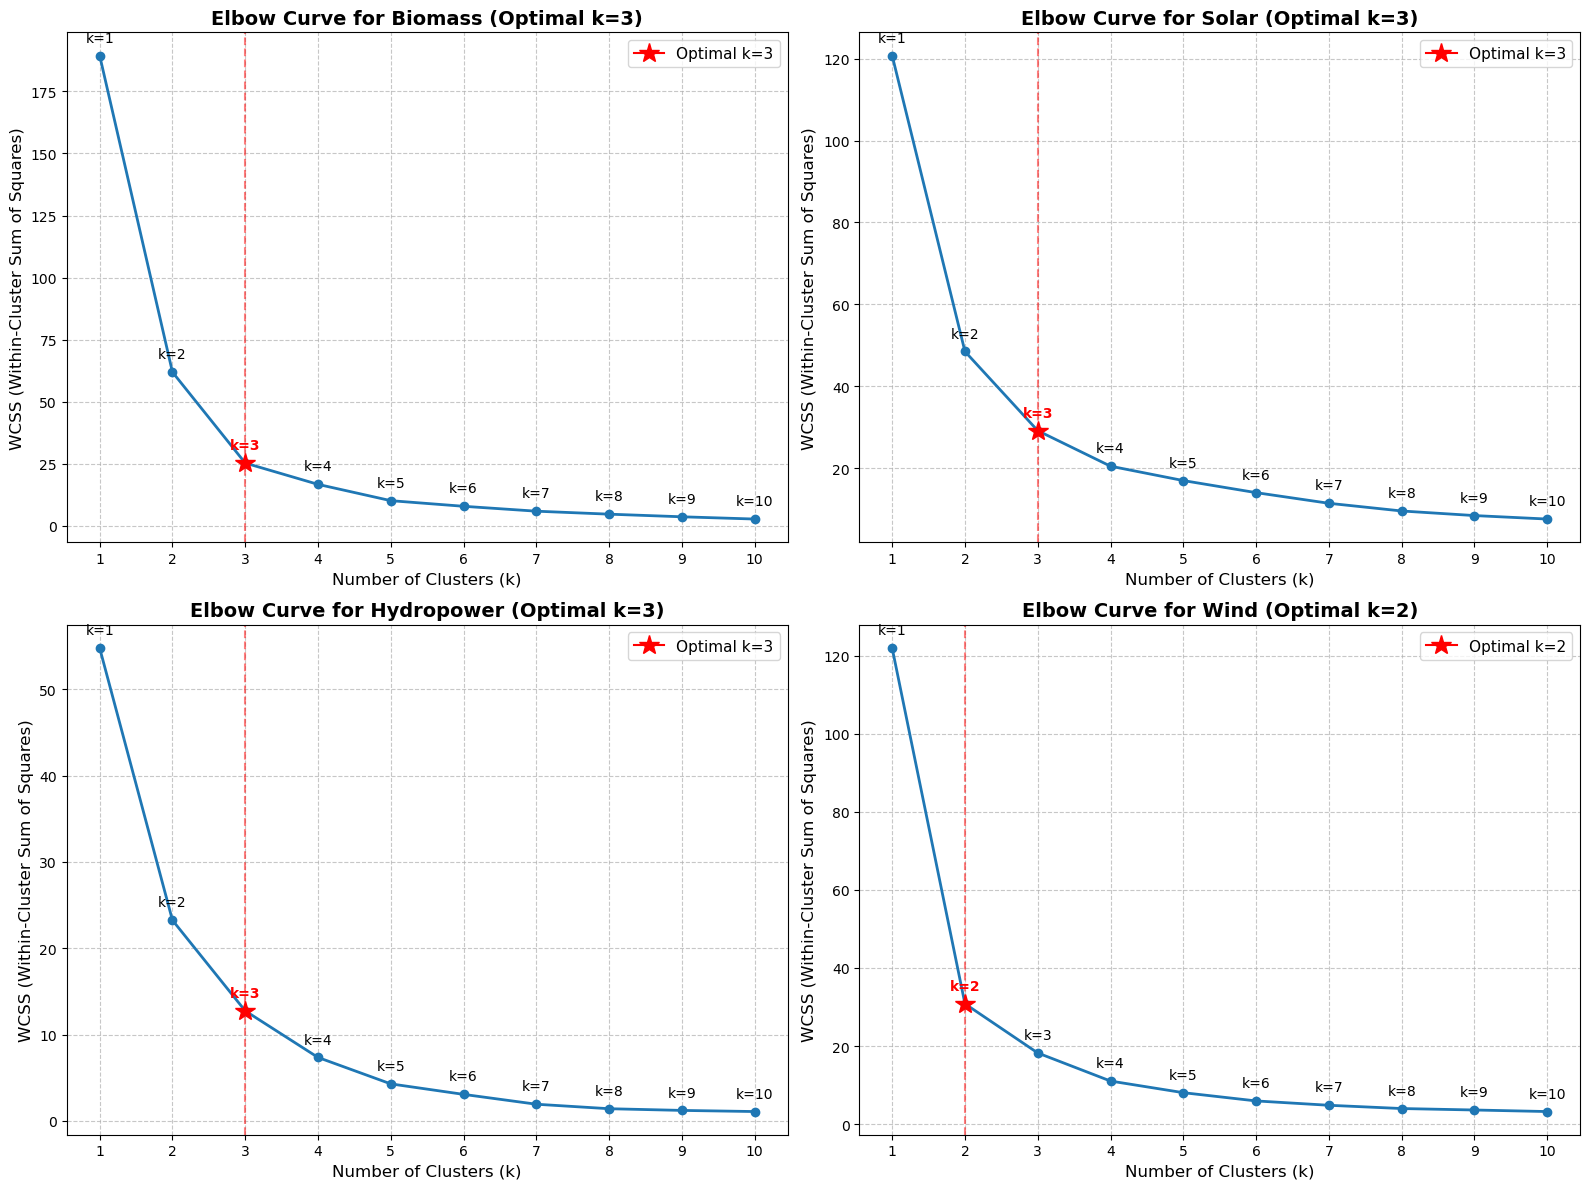

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Veri setini belirtilen dosya yolundan yüklüyoruz
file_path = r"C:\Users\W11\dergi2\processed_data\final\12_final.xlsx"
df = pd.read_excel(file_path)

# İncelenecek enerji türleri
energy_types = ['Biomass', 'Solar', 'Hydropower', 'Wind']

# 2x2'lik bir grafik alanı (figür) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, energy in enumerate(energy_types):
    features = [f'C_{energy}', f'G_{energy}']
    X = df[features].copy()
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    wcss = []
    K_range = list(range(1, 11))
    
    print(f"\n--- Analysis for {energy} Energy ---")
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        wcss_value = kmeans.inertia_
        wcss.append(wcss_value)
        
    # --- OPTIMAL k DEĞERİNİ MATEMATİKSEL OLARAK BULMA ---
    p1 = np.array([K_range[0], wcss[0]])
    p2 = np.array([K_range[-1], wcss[-1]])
    points = np.array([[k, wcss[idx]] for idx, k in enumerate(K_range)])
    distances = np.cross(p2 - p1, points - p1) / np.linalg.norm(p2 - p1)
    
    optimal_k_idx = np.argmax(np.abs(distances))
    optimal_k = K_range[optimal_k_idx]
    optimal_wcss = wcss[optimal_k_idx]
    
    print(f">> Algorithmic Optimal k for {energy}: {optimal_k} <<")

    # --- GRAFİK ÇİZİMİ ---
    axes[i].plot(K_range, wcss, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    
    # Optimum noktayı grafikte kırmızı yıldız ve dikey çizgi ile vurgula
    axes[i].plot(optimal_k, optimal_wcss, marker='*', color='red', markersize=15, 
                 label=f'Optimal k={optimal_k}')
    axes[i].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.5)

    # Grafik üzerindeki her bir noktaya k değerini yazdır
    for j, txt in enumerate(K_range):
        color = 'red' if K_range[j] == optimal_k else 'black'
        weight = 'bold' if K_range[j] == optimal_k else 'normal'
        
        axes[i].annotate(f"k={txt}", 
                         (K_range[j], wcss[j]), 
                         textcoords="offset points", 
                         xytext=(0, 10), 
                         ha='center', 
                         fontsize=10, 
                         color=color,
                         weight=weight)

    # İNGİLİZCE ETİKETLER VE BAŞLIKLAR
    axes[i].set_title(f'Elbow Curve for {energy} (Optimal k={optimal_k})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Number of Clusters (k)', fontsize=12)
    axes[i].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
    axes[i].set_xticks(K_range)
    axes[i].legend(loc='upper right', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# Grafiği kaydetmek isterseniz aşağıdaki satırın başındaki '#' işaretini kaldırabilirsiniz
plt.savefig(r"C:/Users/W11/dergi2/results/figures/elbow_curves_english.png", dpi=300)
plt.show()